<a href="https://colab.research.google.com/github/Pixelsout/Damage-Guided-Adaptive-Recovery-for-Efficient-Neural-Network-Pruning/blob/main/Multidata_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import copy
import numpy as np
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'


Dataset Loader

In [ ]:
def get_dataset(name):

    if name == "CIFAR100":

        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

        trainset = torchvision.datasets.CIFAR100(
            root='./data', train=True, download=True, transform=transform_train)

        testset = torchvision.datasets.CIFAR100(
            root='./data', train=False, download=True, transform=transform_test)

        return trainset, testset, 3, 100


    if name == "FashionMNIST":

        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        trainset = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform)

        testset = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform)

        return trainset, testset, 1, 10


VGGSmall Model

In [ ]:
class VGGSmall(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


Training & Testing

In [ ]:
def train_baseline(model, trainloader, testloader, epochs):

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        if (epoch+1) % 5 == 0:
            acc = test_model(model, testloader)
            print(f"Epoch {epoch+1}/{epochs} | Loss {running_loss:.2f} | Test Acc {acc:.2f}%")

def test_model(model, loader):

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()

    return 100 * correct / total


Global Magnitude Pruning

In [ ]:
def magnitude_prune(model, sparsity):

    all_weights = torch.cat([
        p.abs().view(-1)
        for p in model.parameters()
        if p.dim() > 1
    ])

    k = int(sparsity * all_weights.numel())
    threshold = torch.kthvalue(all_weights, k).values

    with torch.no_grad():
        for p in model.parameters():
            if p.dim() > 1:
                mask = p.abs() > threshold
                p.mul_(mask)


Magnitude Sweep

In [ ]:
def magnitude_sweep(model, dataset_name):

    trainset, testset, in_channels, num_classes = get_dataset(dataset_name)

    testloader = torch.utils.data.DataLoader(testset, batch_size=100)

    baseline_state = copy.deepcopy(model.state_dict())
    baseline_acc = test_model(model, testloader)

    print("\nBaseline:", baseline_acc)

    sparsity_levels = [0.3,0.5,0.7,0.8,0.9]
    results = []

    for s in sparsity_levels:

        temp_model = VGGSmall(in_channels, num_classes).to(device)
        temp_model.load_state_dict(copy.deepcopy(baseline_state))

        magnitude_prune(temp_model, s)

        acc = test_model(temp_model, testloader)

        print(f"Sparsity {int(s*100)}% → {acc:.2f}%")
        results.append((s, acc))

    return baseline_acc, results


Importance Score

In [ ]:
def compute_importance(model, trainloader, mode):

    model.train()
    criterion = nn.CrossEntropyLoss()

    gradients = {}
    activations = {}
    handles = []

    def hook(name):
        def fn(module, inp, out):
            activations[name] = out.detach().abs().mean()
        return fn

    for name, module in model.named_modules():
        if isinstance(module,(nn.Conv2d,nn.Linear)):
            handles.append(module.register_forward_hook(hook(name)))

    for x,y in trainloader:
        x,y = x.to(device), y.to(device)
        model.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()

        for name,p in model.named_parameters():
            if p.grad is not None:
                gradients[name] = p.grad.abs().mean()
        break

    for h in handles:
        h.remove()

    importance = {}

    for name,p in model.named_parameters():
        if p.dim() <= 1:
            continue

        w = p.abs()

        if mode=="magnitude":
            imp = w

        elif mode=="mag_grad":
            imp = w * gradients.get(name, torch.tensor(0.0, device=device))

        elif mode=="mag_grad_act":
            layer = ".".join(name.split(".")[:-1])
            imp = w * gradients.get(name,0) * activations.get(layer,1)

        imp = imp / (imp.mean()+1e-8)

        importance[name] = imp

    return importance


Importance Pruning

In [ ]:
def importance_prune(model, importance, sparsity):

    all_scores = torch.cat([
        v.view(-1) for v in importance.values()
    ])

    k = int(sparsity * all_scores.numel())
    threshold = torch.kthvalue(all_scores, k).values

    with torch.no_grad():
        for name,p in model.named_parameters():
            if name in importance:
                mask = importance[name] > threshold
                p.mul_(mask)


Importance Comparison (50% & 70%)

In [ ]:
def importance_experiment(model, dataset_name):

    trainset, testset, in_channels, num_classes = get_dataset(dataset_name)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=100)

    baseline_state = copy.deepcopy(model.state_dict())
    baseline_acc = test_model(model, testloader)

    print("\nBaseline:", baseline_acc)

    for sparsity in [0.5,0.7]:

        print(f"\n--- {int(sparsity*100)}% ---")

        for mode in ["magnitude","mag_grad","mag_grad_act"]:

            temp_model = VGGSmall(in_channels,num_classes).to(device)
            temp_model.load_state_dict(copy.deepcopy(baseline_state))

            imp = compute_importance(temp_model,trainloader,mode)
            importance_prune(temp_model,imp,sparsity)

            acc = test_model(temp_model,testloader)
            print(mode,"→",acc)


For CIFAR100

In [ ]:
trainset,testset,in_c,num_c = get_dataset("CIFAR100")
trainloader = torch.utils.data.DataLoader(trainset,batch_size=128,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=100)

model_cifar100 = VGGSmall(in_c,num_c).to(device)

train_baseline(model_cifar100,trainloader,testloader,epochs=30)

magnitude_sweep(model_cifar100,"CIFAR100")

importance_experiment(model_cifar100,"CIFAR100")


100%|██████████| 169M/169M [00:03<00:00, 49.3MB/s]


Epoch 5/30 | Loss 937.85 | Test Acc 39.99%
Epoch 10/30 | Loss 698.65 | Test Acc 48.39%
Epoch 15/30 | Loss 574.92 | Test Acc 51.60%
Epoch 20/30 | Loss 494.40 | Test Acc 53.12%
Epoch 25/30 | Loss 439.55 | Test Acc 53.30%
Epoch 30/30 | Loss 397.69 | Test Acc 53.47%

Baseline: 53.47
Sparsity 30% → 53.43%
Sparsity 50% → 53.86%
Sparsity 70% → 53.31%
Sparsity 80% → 46.31%
Sparsity 90% → 3.85%

Baseline: 53.47

--- 50% ---
magnitude → 52.51
mag_grad → 52.39
mag_grad_act → 52.49

--- 70% ---
magnitude → 44.58
mag_grad → 44.56
mag_grad_act → 44.62


For FashionMNIST

In [ ]:
trainset,testset,in_c,num_c = get_dataset("FashionMNIST")
trainloader = torch.utils.data.DataLoader(trainset,batch_size=128,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=100)

model_fashion = VGGSmall(in_c,num_c).to(device)

train_baseline(model_fashion,trainloader,testloader,epochs=20)

magnitude_sweep(model_fashion,"FashionMNIST")

importance_experiment(model_fashion,"FashionMNIST")


100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


Epoch 5/20 | Loss 79.16 | Test Acc 92.27%
Epoch 10/20 | Loss 34.97 | Test Acc 92.11%
Epoch 15/20 | Loss 18.47 | Test Acc 92.04%
Epoch 20/20 | Loss 14.19 | Test Acc 92.21%

Baseline: 92.21
Sparsity 30% → 92.25%
Sparsity 50% → 92.08%
Sparsity 70% → 91.95%
Sparsity 80% → 91.32%
Sparsity 90% → 82.88%

Baseline: 92.21

--- 50% ---
magnitude → 92.0
mag_grad → 92.04
mag_grad_act → 92.05

--- 70% ---
magnitude → 74.57
mag_grad → 70.67
mag_grad_act → 71.43


next phase


In [ ]:
def collect_results(dataset_name, model, epochs):

    trainset, testset, in_channels, num_classes = get_dataset(dataset_name)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=100)

    baseline_state = copy.deepcopy(model.state_dict())
    baseline_acc = test_model(model, testloader)

    sparsity_levels = [0.3, 0.5, 0.7, 0.8, 0.9]

    magnitude_results = {}
    importance_results = {}

    # Magnitude Sweep
    for s in sparsity_levels:
        temp_model = VGGSmall(in_channels, num_classes).to(device)
        temp_model.load_state_dict(copy.deepcopy(baseline_state))
        magnitude_prune(temp_model, s)
        acc = test_model(temp_model, testloader)
        magnitude_results[s] = acc

    # Importance Comparison (50% and 70%)
    for s in [0.5, 0.7]:

        importance_results[s] = {}

        for mode in ["magnitude", "mag_grad", "mag_grad_act"]:

            temp_model = VGGSmall(in_channels, num_classes).to(device)
            temp_model.load_state_dict(copy.deepcopy(baseline_state))

            imp = compute_importance(temp_model, trainloader, mode)
            importance_prune(temp_model, imp, s)

            acc = test_model(temp_model, testloader)
            importance_results[s][mode] = acc

    return {
        "Baseline": baseline_acc,
        "Magnitude_Sweep": magnitude_results,
        "Importance": importance_results
    }

In [ ]:
cifar100_results = collect_results("CIFAR100", model_cifar100, epochs=30)
fashion_results = collect_results("FashionMNIST", model_fashion, epochs=20)

In [ ]:
def find_breaking_point(results):

    baseline = results["Baseline"]
    sweep = results["Magnitude_Sweep"]

    for sparsity, acc in sweep.items():
        drop = baseline - acc
        if drop > 10:  # >10% drop threshold
            return sparsity

    return None

In [ ]:
print("CIFAR100 Breaking Point:", find_breaking_point(cifar100_results))
print("FashionMNIST Breaking Point:", find_breaking_point(fashion_results))

CIFAR100 Breaking Point: 0.9
FashionMNIST Breaking Point: None


In [ ]:
import matplotlib.pyplot as plt

def plot_sparsity_curve(dataset_name, results):

    sparsities = list(results["Magnitude_Sweep"].keys())
    accuracies = list(results["Magnitude_Sweep"].values())

    plt.figure()
    plt.plot([s*100 for s in sparsities], accuracies, marker='o')
    plt.xlabel("Sparsity (%)")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{dataset_name} Accuracy vs Sparsity")
    plt.show()

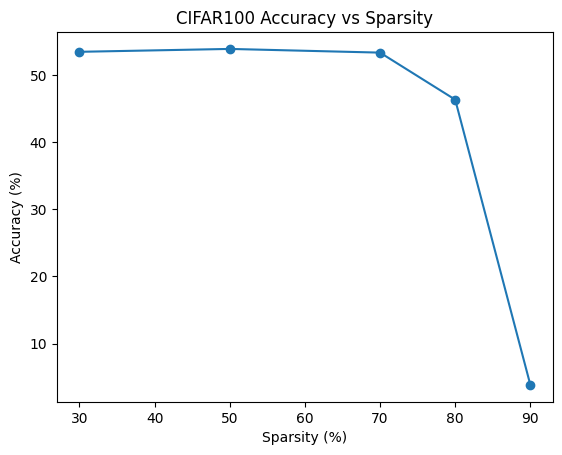

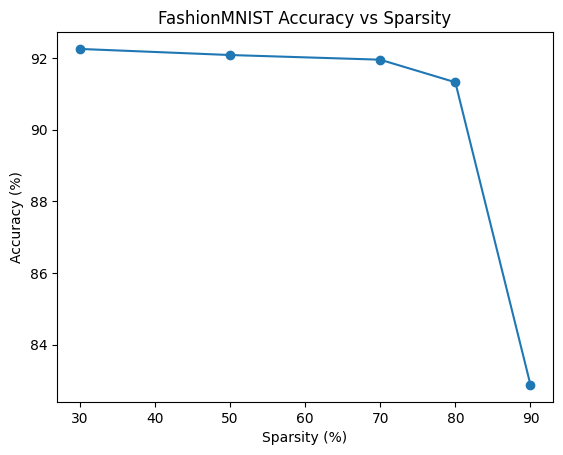

In [ ]:
plot_sparsity_curve("CIFAR100", cifar100_results)
plot_sparsity_curve("FashionMNIST", fashion_results)

In [ ]:
def generate_summary(dataset_name, results):

    baseline = results["Baseline"]
    breaking = find_breaking_point(results)

    print("\n==============================")
    print("Research Summary:", dataset_name)
    print("==============================")

    print(f"Baseline Accuracy: {baseline:.2f}%")

    if breaking:
        print(f"Breaking Point begins at ~{int(breaking*100)}% sparsity.")
    else:
        print("No major breaking point detected within tested sparsities.")

    imp = results["Importance"]

    for s in imp:
        mag = imp[s]["magnitude"]
        grad = imp[s]["mag_grad"]
        act = imp[s]["mag_grad_act"]

        print(f"\nAt {int(s*100)}%:")
        print(f"Mag → {mag:.2f}%")
        print(f"Mag+Grad → {grad:.2f}%")
        print(f"Mag+Grad+Act → {act:.2f}%")

        if grad > mag:
            print("Gradient improves pruning.")
        else:
            print("Gradient adds limited benefit.")

In [ ]:
generate_summary("CIFAR100", cifar100_results)
generate_summary("FashionMNIST", fashion_results)


Research Summary: CIFAR100
Baseline Accuracy: 53.47%
Breaking Point begins at ~90% sparsity.

At 50%:
Mag → 52.51%
Mag+Grad → 52.38%
Mag+Grad+Act → 52.51%
Gradient adds limited benefit.

At 70%:
Mag → 44.58%
Mag+Grad → 44.65%
Mag+Grad+Act → 44.61%
Gradient improves pruning.

Research Summary: FashionMNIST
Baseline Accuracy: 92.21%
No major breaking point detected within tested sparsities.

At 50%:
Mag → 92.00%
Mag+Grad → 92.05%
Mag+Grad+Act → 92.03%
Gradient improves pruning.

At 70%:
Mag → 74.57%
Mag+Grad → 70.63%
Mag+Grad+Act → 71.40%
Gradient adds limited benefit.


adaptive pruning

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import copy

device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [ ]:
def get_dataset(name):

    if name in ["CIFAR10", "CIFAR100"]:

        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

        if name == "CIFAR10":
            trainset = torchvision.datasets.CIFAR10(
                root='./data', train=True, download=True, transform=transform_train)
            testset = torchvision.datasets.CIFAR10(
                root='./data', train=False, download=True, transform=transform_test)
            return trainset, testset, 3, 10

        else:
            trainset = torchvision.datasets.CIFAR100(
                root='./data', train=True, download=True, transform=transform_train)
            testset = torchvision.datasets.CIFAR100(
                root='./data', train=False, download=True, transform=transform_test)
            return trainset, testset, 3, 100

    if name == "FashionMNIST":

        transform = transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        trainset = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform)
        testset = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform)

        return trainset, testset, 1, 10


In [ ]:
class VGGSmall(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256*4*4, 512), nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [ ]:
def train_baseline(model, trainloader, testloader, epochs):

    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        if (epoch+1) % 5 == 0:
            acc = test_model(model, testloader)
            print(f"Epoch {epoch+1}/{epochs} | Acc {acc:.2f}%")

def test_model(model, loader):

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()

    return 100 * correct / total


Uniform Pruning

In [ ]:
def uniform_prune(model, sparsity):

    all_weights = torch.cat([
        p.abs().view(-1)
        for p in model.parameters()
        if p.dim() > 1
    ])

    k = int(sparsity * all_weights.numel())
    threshold = torch.kthvalue(all_weights, k).values

    with torch.no_grad():
        for p in model.parameters():
            if p.dim() > 1:
                mask = p.abs() > threshold
                p.mul_(mask)


damage comparision

In [ ]:
def compute_layer_damage(model_orig, model_pruned, loader):

    model_orig.eval()
    model_pruned.eval()

    act_orig = {}
    act_pruned = {}

    def hook(store, name):
        def fn(module, inp, out):
            store[name] = out.detach()
        return fn

    handles = []

    for (n1, m1), (n2, m2) in zip(
        model_orig.named_modules(),
        model_pruned.named_modules()
    ):
        if isinstance(m1, (nn.Conv2d, nn.Linear)):
            handles.append(m1.register_forward_hook(hook(act_orig, n1)))
            handles.append(m2.register_forward_hook(hook(act_pruned, n2)))

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            model_orig(x)
            model_pruned(x)
            break

    for h in handles:
        h.remove()

    damage = {}

    for name in act_orig:
        diff = act_orig[name] - act_pruned[name]
        damage[name] = diff.pow(2).mean().item()

    return damage


adaptive prune

In [ ]:
def adaptive_prune_stable(model, damage_scores, global_sparsity=0.7, beta=0.15):

    # Collect parameter-level mapping to layer damage
    param_damage = {}

    for name, p in model.named_parameters():
        if p.dim() > 1:
            layer_name = ".".join(name.split(".")[:-1])
            if layer_name in damage_scores:
                param_damage[name] = damage_scores[layer_name]

    if len(param_damage) == 0:
        print("No damage scores matched parameters.")
        return

    # Normalize damage to [0,1]
    damages = np.array(list(param_damage.values()))
    min_d, max_d = damages.min(), damages.max()

    norm_damage = {}
    for k in param_damage:
        d = param_damage[k]
        if max_d - min_d < 1e-8:
            norm_damage[k] = 0.0
        else:
            norm_damage[k] = (d - min_d) / (max_d - min_d)

    # Conservative sparsity allocation
    sparsity_alloc = {}

    for name in norm_damage:

        s_l = global_sparsity - beta * norm_damage[name]

        # Clamp to safe range
        s_l = max(0.1, min(0.9, s_l))

        sparsity_alloc[name] = s_l

    # Apply pruning per layer
    with torch.no_grad():
        for name, p in model.named_parameters():

            if name not in sparsity_alloc:
                continue

            s = sparsity_alloc[name]

            flat = p.abs().view(-1)
            k = int(s * flat.numel())

            if k <= 0 or k >= flat.numel():
                continue

            threshold = torch.kthvalue(flat, k).values
            mask = p.abs() > threshold
            p.mul_(mask)


In [ ]:
def adaptive_vs_uniform(dataset_name, epochs, sparsity=0.7):

    uniform_results = []
    adaptive_results = []

    for seed in [0,1,2]:

        torch.manual_seed(seed)

        trainset, testset, in_c, num_c = get_dataset(dataset_name)

        trainloader = torch.utils.data.DataLoader(
            trainset, batch_size=128, shuffle=True
        )
        testloader = torch.utils.data.DataLoader(
            testset, batch_size=100
        )

        model = VGGSmall(in_c, num_c).to(device)
        train_baseline(model, trainloader, testloader, epochs)

        baseline_state = copy.deepcopy(model.state_dict())

        # ------------------------
        # Uniform Pruning
        # ------------------------
        model_u = VGGSmall(in_c, num_c).to(device)
        model_u.load_state_dict(copy.deepcopy(baseline_state))

        uniform_prune(model_u, sparsity)
        u_acc = test_model(model_u, testloader)

        # ------------------------
        # Adaptive Pruning (Stable)
        # ------------------------
        model_a = VGGSmall(in_c, num_c).to(device)
        model_a.load_state_dict(copy.deepcopy(baseline_state))

        damage = compute_layer_damage(model, model_u, testloader)

        adaptive_prune_stable(
            model_a,
            damage,
            global_sparsity=sparsity,
            beta=0.15
        )

        a_acc = test_model(model_a, testloader)

        uniform_results.append(u_acc)
        adaptive_results.append(a_acc)

    print("\nDataset:", dataset_name)
    print("Uniform mean ± std:",
          np.mean(uniform_results),
          "±",
          np.std(uniform_results))
    print("Adaptive mean ± std:",
          np.mean(adaptive_results),
          "±",
          np.std(adaptive_results))

    return uniform_results, adaptive_results


In [ ]:
cifar10_stats = adaptive_vs_uniform("CIFAR10", epochs=30)
cifar100_stats = adaptive_vs_uniform("CIFAR100", epochs=30)
fashion_stats = adaptive_vs_uniform("FashionMNIST", epochs=20)


Epoch 5/30 | Acc 76.71%
Epoch 10/30 | Acc 81.42%
Epoch 15/30 | Acc 82.90%
Epoch 20/30 | Acc 85.20%
Epoch 25/30 | Acc 85.06%
Epoch 30/30 | Acc 85.15%
Epoch 5/30 | Acc 76.22%
Epoch 10/30 | Acc 83.06%
Epoch 15/30 | Acc 84.50%
Epoch 20/30 | Acc 85.15%
Epoch 25/30 | Acc 85.82%
Epoch 30/30 | Acc 85.80%
Epoch 5/30 | Acc 76.20%
Epoch 10/30 | Acc 82.47%
Epoch 15/30 | Acc 85.09%
Epoch 20/30 | Acc 85.70%
Epoch 25/30 | Acc 85.54%
Epoch 30/30 | Acc 86.35%

Dataset: CIFAR10
Uniform mean ± std: 84.76666666666667 ± 0.14522013940527945
Adaptive mean ± std: 56.126666666666665 ± 9.340664977517509
Epoch 5/30 | Acc 35.34%
Epoch 10/30 | Acc 45.86%
Epoch 15/30 | Acc 49.35%
Epoch 20/30 | Acc 50.66%
Epoch 25/30 | Acc 51.85%
Epoch 30/30 | Acc 52.14%
Epoch 5/30 | Acc 33.95%
Epoch 10/30 | Acc 43.48%
Epoch 15/30 | Acc 47.36%
Epoch 20/30 | Acc 50.37%
Epoch 25/30 | Acc 51.47%
Epoch 30/30 | Acc 51.24%
Epoch 5/30 | Acc 36.72%
Epoch 10/30 | Acc 47.74%
Epoch 15/30 | Acc 51.32%
Epoch 20/30 | Acc 51.24%
Epoch 25/30 | Acc 

Damage based layer ranking

In [ ]:
def get_critical_layers(damage_scores, top_ratio=0.3):

    sorted_layers = sorted(
        damage_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    k = int(len(sorted_layers) * top_ratio)

    critical = [name for name, _ in sorted_layers[:k]]

    return critical


Focused Fine-Tuning Module

In [ ]:
def focused_finetune(model, critical_layers, trainloader, testloader, epochs=6):

    # Freeze all layers first
    for name, param in model.named_parameters():
        layer_name = ".".join(name.split(".")[:-1])
        param.requires_grad = layer_name in critical_layers

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-4
    )

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

        acc = test_model(model, testloader)
        print(f"Recovery Epoch {epoch+1}/{epochs} | Acc {acc:.2f}%")

    return test_model(model, testloader)


New Adaptive Experiment

In [ ]:
def adaptive_recovery_experiment(dataset_name, epochs, sparsity=0.7):

    torch.manual_seed(0)

    trainset, testset, in_c, num_c = get_dataset(dataset_name)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=100)

    model = VGGSmall(in_c, num_c).to(device)
    train_baseline(model, trainloader, testloader, epochs)

    baseline_acc = test_model(model, testloader)
    print("Baseline:", baseline_acc)

    baseline_state = copy.deepcopy(model.state_dict())

    # Uniform pruning
    model_pruned = VGGSmall(in_c, num_c).to(device)
    model_pruned.load_state_dict(copy.deepcopy(baseline_state))
    uniform_prune(model_pruned, sparsity)

    uniform_acc = test_model(model_pruned, testloader)
    print("After Uniform Pruning:", uniform_acc)

    # Damage analysis
    damage = compute_layer_damage(model, model_pruned, testloader)

    critical_layers = get_critical_layers(damage, top_ratio=0.3)

    # Focused fine-tuning
    recovered_acc = focused_finetune(
        model_pruned,
        critical_layers,
        trainloader,
        testloader,
        epochs=6
    )

    print("After Adaptive Recovery:", recovered_acc)

    return {
        "Baseline": baseline_acc,
        "Uniform": uniform_acc,
        "Recovered": recovered_acc
    }


In [ ]:
cifar10_recovery = adaptive_recovery_experiment("CIFAR10", epochs=30)
cifar100_recovery = adaptive_recovery_experiment("CIFAR100", epochs=30)
fashion_recovery = adaptive_recovery_experiment("FashionMNIST", epochs=20)


Epoch 5/30 | Acc 76.09%
Epoch 10/30 | Acc 81.94%
Epoch 15/30 | Acc 83.85%
Epoch 20/30 | Acc 85.32%
Epoch 25/30 | Acc 85.18%
Epoch 30/30 | Acc 85.67%
Baseline: 85.67
After Uniform Pruning: 85.2
Recovery Epoch 1/6 | Acc 85.86%
Recovery Epoch 2/6 | Acc 85.91%
Recovery Epoch 3/6 | Acc 86.09%
Recovery Epoch 4/6 | Acc 85.99%
Recovery Epoch 5/6 | Acc 86.10%
Recovery Epoch 6/6 | Acc 85.77%
After Adaptive Recovery: 85.77
Epoch 5/30 | Acc 37.00%
Epoch 10/30 | Acc 47.43%
Epoch 15/30 | Acc 50.24%
Epoch 20/30 | Acc 51.95%
Epoch 25/30 | Acc 52.40%
Epoch 30/30 | Acc 52.38%
Baseline: 52.38
After Uniform Pruning: 51.75
Recovery Epoch 1/6 | Acc 54.53%
Recovery Epoch 2/6 | Acc 54.26%
Recovery Epoch 3/6 | Acc 54.42%
Recovery Epoch 4/6 | Acc 54.81%
Recovery Epoch 5/6 | Acc 54.88%
Recovery Epoch 6/6 | Acc 54.89%
After Adaptive Recovery: 54.89
Epoch 5/20 | Acc 91.62%
Epoch 10/20 | Acc 91.46%
Epoch 15/20 | Acc 92.52%
Epoch 20/20 | Acc 92.19%
Baseline: 92.19
After Uniform Pruning: 91.84
Recovery Epoch 1/6 | Ac